In [1]:
# ============================================================
# PASSO 2 — PORTAS TRANSVERSAIS E INJEÇÃO DE ERROS EM QISKIT
# ============================================================
#
# Instalação recomendada:
# pip install qiskit qiskit-aer matplotlib pylatexenc
#
# Este código implementa:
# 1. Código de repetição de 3 qubits para bit flip;
# 2. Extração de síndrome com qubits auxiliares;
# 3. CNOT transversal entre blocos codificados;
# 4. Código de Shor de 9 qubits;
# 5. Injeção controlada de erros Pauli X, Y, Z;
# 6. Leitura de estabilizadores do código de Shor;
# 7. Simulação ideal e simulação com ruído despolarizante.
#
# ============================================================

from collections import Counter

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit.quantum_info import Statevector, SparsePauliOp


# ============================================================
# FUNÇÕES AUXILIARES
# ============================================================

def simulate_counts(qc, shots=2048, noise_model=None):
    """
    Executa um circuito no AerSimulator e retorna os counts.
    """

    simulator = AerSimulator(noise_model=noise_model)
    compiled = transpile(qc, simulator)
    result = simulator.run(compiled, shots=shots).result()

    return result.get_counts()


def add_all_measurements(qc):
    """
    Cria uma cópia do circuito com medição de todos os qubits.
    Mede q[i] em c[i].
    """

    measured = QuantumCircuit(qc.num_qubits, qc.num_qubits)
    measured.compose(qc, qubits=range(qc.num_qubits), inplace=True)
    measured.measure(range(qc.num_qubits), range(qc.num_qubits))

    return measured


def classical_bit(bitstring, index):
    """
    Lê o bit clássico c[index] de uma bitstring do Qiskit.

    O Qiskit imprime a string na ordem c[n-1]...c[0].
    Por isso, invertemos a string.
    """

    clean = bitstring.replace(" ", "")
    return int(clean[::-1][index])


def top_counts(counts, k=10):
    """
    Retorna apenas os k resultados mais frequentes.
    """

    return dict(
        sorted(counts.items(), key=lambda item: item[1], reverse=True)[:k]
    )


def inject_pauli_error(qc, qubit, pauli):
    """
    Injeta erro Pauli controlado em um qubit físico.
    """

    if pauli is None:
        return

    pauli = pauli.upper()

    if pauli == "X":
        qc.x(qubit)
    elif pauli == "Y":
        qc.y(qubit)
    elif pauli == "Z":
        qc.z(qubit)
    else:
        raise ValueError("O erro deve ser 'X', 'Y', 'Z' ou None.")


def build_depolarizing_noise_model(p1=0.001, p2=0.01):
    """
    Modelo simples de ruído despolarizante.

    p1: probabilidade de erro em portas de 1 qubit.
    p2: probabilidade de erro em portas de 2 qubits.
    """

    noise_model = NoiseModel()

    one_qubit_error = depolarizing_error(p1, 1)
    two_qubit_error = depolarizing_error(p2, 2)

    noise_model.add_all_qubit_quantum_error(
        one_qubit_error,
        ["x", "y", "z", "h"]
    )

    noise_model.add_all_qubit_quantum_error(
        two_qubit_error,
        ["cx"]
    )

    return noise_model


# ============================================================
# PARTE 1 — CÓDIGO DE REPETIÇÃO DE 3 QUBITS
# ============================================================

def encode_repetition_bitflip(qc, data_qubits=(0, 1, 2), logical_state="0"):
    """
    Codifica um qubit lógico no código de repetição de 3 qubits.

    |0>_L = |000>
    |1>_L = |111>
    """

    q0, q1, q2 = data_qubits

    if logical_state == "1":
        qc.x(q0)
    elif logical_state == "0":
        pass
    else:
        raise ValueError("logical_state deve ser '0' ou '1'.")

    qc.cx(q0, q1)
    qc.cx(q0, q2)


def build_repetition_syndrome_circuit(
    logical_state="0",
    error_qubit=None,
    pauli_error=None
):
    """
    Código de repetição com extração de síndrome.

    Qubits:
    q0, q1, q2: qubits de dados
    q3, q4: qubits auxiliares de síndrome

    Síndromes:
    s01 = paridade entre q0 e q1
    s12 = paridade entre q1 e q2
    """

    qc = QuantumCircuit(5, 5)

    encode_repetition_bitflip(
        qc,
        data_qubits=(0, 1, 2),
        logical_state=logical_state
    )

    if error_qubit is not None:
        inject_pauli_error(qc, error_qubit, pauli_error)

    # Extração de síndrome Z0 Z1
    qc.cx(0, 3)
    qc.cx(1, 3)

    # Extração de síndrome Z1 Z2
    qc.cx(1, 4)
    qc.cx(2, 4)

    qc.measure([0, 1, 2, 3, 4], [0, 1, 2, 3, 4])

    return qc


def summarize_repetition_syndrome(counts):
    """
    Resume os resultados do código de repetição.

    Retorna:
    - distribuição das síndromes;
    - distribuição lógica por voto majoritário.
    """

    syndrome_counts = Counter()
    logical_counts = Counter()

    for bitstring, freq in counts.items():
        b0 = classical_bit(bitstring, 0)
        b1 = classical_bit(bitstring, 1)
        b2 = classical_bit(bitstring, 2)
        s01 = classical_bit(bitstring, 3)
        s12 = classical_bit(bitstring, 4)

        syndrome = f"{s01}{s12}"
        syndrome_counts[syndrome] += freq

        logical_value = 1 if (b0 + b1 + b2) >= 2 else 0
        logical_counts[str(logical_value)] += freq

    return dict(syndrome_counts), dict(logical_counts)


def interpret_repetition_syndrome(syndrome):
    """
    Interpretação das síndromes do código de repetição.
    """

    table = {
        "00": "sem erro detectável",
        "10": "erro provável em q0",
        "11": "erro provável em q1",
        "01": "erro provável em q2",
    }

    return table.get(syndrome, "síndrome desconhecida")


# ============================================================
# PARTE 2 — CNOT TRANSVERSAL NO CÓDIGO DE REPETIÇÃO
# ============================================================

def build_repetition_transversal_cnot(
    control_state="1",
    target_state="0",
    error_qubit=None,
    pauli_error=None
):
    """
    Implementa uma CNOT transversal entre dois blocos codificados.

    Bloco controle: q0, q1, q2
    Bloco alvo:     q3, q4, q5
    """

    qc = QuantumCircuit(6, 6)

    encode_repetition_bitflip(
        qc,
        data_qubits=(0, 1, 2),
        logical_state=control_state
    )

    encode_repetition_bitflip(
        qc,
        data_qubits=(3, 4, 5),
        logical_state=target_state
    )

    if error_qubit is not None:
        inject_pauli_error(qc, error_qubit, pauli_error)

    # CNOT lógica transversal
    qc.cx(0, 3)
    qc.cx(1, 4)
    qc.cx(2, 5)

    qc.measure(range(6), range(6))

    return qc


def summarize_two_repetition_blocks(counts):
    """
    Decodifica dois blocos de repetição por voto majoritário.
    """

    logical_counts = Counter()

    for bitstring, freq in counts.items():
        block_a = [
            classical_bit(bitstring, 0),
            classical_bit(bitstring, 1),
            classical_bit(bitstring, 2),
        ]

        block_b = [
            classical_bit(bitstring, 3),
            classical_bit(bitstring, 4),
            classical_bit(bitstring, 5),
        ]

        logical_a = 1 if sum(block_a) >= 2 else 0
        logical_b = 1 if sum(block_b) >= 2 else 0

        logical_counts[f"{logical_a}{logical_b}"] += freq

    return dict(logical_counts)


# ============================================================
# PARTE 3 — CÓDIGO DE SHOR DE 9 QUBITS
# ============================================================

def encode_shor_block(qc, offset=0, logical_state="0"):
    """
    Codifica um qubit no código de Shor de 9 qubits.

    Estados permitidos:
    logical_state = "0", "1", "+", "-"
    """

    q = [offset + i for i in range(9)]

    if logical_state == "0":
        pass
    elif logical_state == "1":
        qc.x(q[0])
    elif logical_state == "+":
        qc.h(q[0])
    elif logical_state == "-":
        qc.x(q[0])
        qc.h(q[0])
    else:
        raise ValueError("logical_state deve ser '0', '1', '+' ou '-'.")

    # Primeira camada: repetição contra phase flip
    qc.cx(q[0], q[3])
    qc.cx(q[0], q[6])

    qc.h(q[0])
    qc.h(q[3])
    qc.h(q[6])

    # Segunda camada: repetição contra bit flip em cada bloco
    qc.cx(q[0], q[1])
    qc.cx(q[0], q[2])

    qc.cx(q[3], q[4])
    qc.cx(q[3], q[5])

    qc.cx(q[6], q[7])
    qc.cx(q[6], q[8])


def build_shor_single_block(
    logical_state="0",
    error_qubit=None,
    pauli_error=None,
    transversal_gate=None
):
    """
    Prepara um bloco de Shor, injeta erro Pauli opcional
    e aplica opcionalmente uma porta transversal X ou Z.

    transversal_gate:
    None, "X", "Z"
    """

    qc = QuantumCircuit(9)

    encode_shor_block(qc, offset=0, logical_state=logical_state)

    if error_qubit is not None:
        inject_pauli_error(qc, error_qubit, pauli_error)

    if transversal_gate is not None:
        transversal_gate = transversal_gate.upper()

        if transversal_gate == "X":
            for i in range(9):
                qc.x(i)

        elif transversal_gate == "Z":
            for i in range(9):
                qc.z(i)

        else:
            raise ValueError("transversal_gate deve ser None, 'X' ou 'Z'.")

    return qc


# ============================================================
# PARTE 4 — ESTABILIZADORES DO CÓDIGO DE SHOR
# ============================================================

SHOR_STABILIZERS = [
    ("Z0 Z1", {0: "Z", 1: "Z"}),
    ("Z1 Z2", {1: "Z", 2: "Z"}),
    ("Z3 Z4", {3: "Z", 4: "Z"}),
    ("Z4 Z5", {4: "Z", 5: "Z"}),
    ("Z6 Z7", {6: "Z", 7: "Z"}),
    ("Z7 Z8", {7: "Z", 8: "Z"}),
    ("X0 X1 X2 X3 X4 X5", {0: "X", 1: "X", 2: "X", 3: "X", 4: "X", 5: "X"}),
    ("X3 X4 X5 X6 X7 X8", {3: "X", 4: "X", 5: "X", 6: "X", 7: "X", 8: "X"}),
]


def pauli_operator(num_qubits, local_ops):
    """
    Constrói um SparsePauliOp.

    Atenção:
    no Qiskit, o caractere mais à direita da string de Pauli
    atua no qubit 0.
    """

    label = ["I"] * num_qubits

    for qubit, pauli in local_ops.items():
        label[num_qubits - 1 - qubit] = pauli

    return SparsePauliOp("".join(label))


def shor_stabilizer_expectations(qc, offset=0):
    """
    Calcula os valores esperados dos estabilizadores do código de Shor.

    offset permite analisar blocos deslocados:
    - offset=0 para o primeiro bloco;
    - offset=9 para o segundo bloco em circuitos de 18 qubits.
    """

    sv = Statevector.from_instruction(qc)
    table = []

    for name, ops in SHOR_STABILIZERS:
        shifted_ops = {offset + qubit: pauli for qubit, pauli in ops.items()}
        op = pauli_operator(qc.num_qubits, shifted_ops)

        value = float(sv.expectation_value(op).real)

        if value > 0.5:
            sign = "+1"
        elif value < -0.5:
            sign = "-1"
        else:
            sign = "0"

        table.append((name, sign, round(value, 6)))

    return table


def print_stabilizer_table(title, table):
    """
    Imprime tabela de estabilizadores.
    """

    print("\n" + title)
    print("-" * len(title))

    for name, sign, value in table:
        print(f"{name:25s}  sinal = {sign:>2s}   valor = {value: .6f}")


# ============================================================
# PARTE 5 — CNOT TRANSVERSAL ENTRE DOIS BLOCOS DE SHOR
# ============================================================

def build_shor_transversal_cnot(
    control_state="1",
    target_state="0",
    error_block=None,
    error_position=None,
    pauli_error=None
):
    """
    Implementa CNOT transversal entre dois blocos de Shor.

    Bloco controle: q0  a q8
    Bloco alvo:     q9  a q17

    error_block:
    None, "control", "target"

    error_position:
    posição interna do bloco, de 0 a 8.
    """

    qc = QuantumCircuit(18)

    encode_shor_block(qc, offset=0, logical_state=control_state)
    encode_shor_block(qc, offset=9, logical_state=target_state)

    if error_block is not None:
        if error_position is None:
            raise ValueError("Defina error_position entre 0 e 8.")

        if error_block == "control":
            physical_qubit = error_position
        elif error_block == "target":
            physical_qubit = 9 + error_position
        else:
            raise ValueError("error_block deve ser None, 'control' ou 'target'.")

        inject_pauli_error(qc, physical_qubit, pauli_error)

    # CNOT transversal entre os blocos
    for i in range(9):
        qc.cx(i, 9 + i)

    return qc


# ============================================================
# EXECUÇÃO DOS EXPERIMENTOS
# ============================================================

print("\n============================================================")
print("EXPERIMENTO 1 — CÓDIGO DE REPETIÇÃO SEM ERRO")
print("============================================================")

qc_rep_no_error = build_repetition_syndrome_circuit(
    logical_state="0",
    error_qubit=None,
    pauli_error=None
)

counts_rep_no_error = simulate_counts(qc_rep_no_error)
syndrome_no_error, logical_no_error = summarize_repetition_syndrome(counts_rep_no_error)

print("Counts:", counts_rep_no_error)
print("Síndromes:", syndrome_no_error)
print("Decodificação lógica:", logical_no_error)

for syndrome in syndrome_no_error:
    print(f"Síndrome {syndrome}: {interpret_repetition_syndrome(syndrome)}")


print("\n============================================================")
print("EXPERIMENTO 2 — CÓDIGO DE REPETIÇÃO COM ERRO X EM q1")
print("============================================================")

qc_rep_x_error = build_repetition_syndrome_circuit(
    logical_state="0",
    error_qubit=1,
    pauli_error="X"
)

counts_rep_x_error = simulate_counts(qc_rep_x_error)
syndrome_x_error, logical_x_error = summarize_repetition_syndrome(counts_rep_x_error)

print("Counts:", counts_rep_x_error)
print("Síndromes:", syndrome_x_error)
print("Decodificação lógica:", logical_x_error)

for syndrome in syndrome_x_error:
    print(f"Síndrome {syndrome}: {interpret_repetition_syndrome(syndrome)}")


print("\n============================================================")
print("EXPERIMENTO 3 — CNOT TRANSVERSAL ENTRE BLOCOS DE REPETIÇÃO")
print("============================================================")

qc_rep_tcnot = build_repetition_transversal_cnot(
    control_state="1",
    target_state="0",
    error_qubit=None,
    pauli_error=None
)

counts_rep_tcnot = simulate_counts(qc_rep_tcnot)
logical_rep_tcnot = summarize_two_repetition_blocks(counts_rep_tcnot)

print("Counts:", counts_rep_tcnot)
print("Decodificação lógica dos blocos:", logical_rep_tcnot)


print("\n============================================================")
print("EXPERIMENTO 4 — CNOT TRANSVERSAL COM ERRO X NO CONTROLE")
print("============================================================")

qc_rep_tcnot_error = build_repetition_transversal_cnot(
    control_state="1",
    target_state="0",
    error_qubit=1,
    pauli_error="X"
)

counts_rep_tcnot_error = simulate_counts(qc_rep_tcnot_error)
logical_rep_tcnot_error = summarize_two_repetition_blocks(counts_rep_tcnot_error)

print("Counts:", counts_rep_tcnot_error)
print("Decodificação lógica dos blocos:", logical_rep_tcnot_error)


print("\n============================================================")
print("EXPERIMENTO 5 — CÓDIGO DE SHOR SEM ERRO")
print("============================================================")

qc_shor_no_error = build_shor_single_block(
    logical_state="0",
    error_qubit=None,
    pauli_error=None
)

table_shor_no_error = shor_stabilizer_expectations(qc_shor_no_error)
print_stabilizer_table("Estabilizadores do Shor sem erro", table_shor_no_error)

counts_shor_no_error = simulate_counts(add_all_measurements(qc_shor_no_error))
print("Top counts:", top_counts(counts_shor_no_error))


print("\n============================================================")
print("EXPERIMENTO 6 — CÓDIGO DE SHOR COM ERRO X EM q4")
print("============================================================")

qc_shor_x_error = build_shor_single_block(
    logical_state="0",
    error_qubit=4,
    pauli_error="X"
)

table_shor_x_error = shor_stabilizer_expectations(qc_shor_x_error)
print_stabilizer_table("Estabilizadores do Shor com erro X em q4", table_shor_x_error)

counts_shor_x_error = simulate_counts(add_all_measurements(qc_shor_x_error))
print("Top counts:", top_counts(counts_shor_x_error))


print("\n============================================================")
print("EXPERIMENTO 7 — CÓDIGO DE SHOR COM ERRO Z EM q4")
print("============================================================")

qc_shor_z_error = build_shor_single_block(
    logical_state="0",
    error_qubit=4,
    pauli_error="Z"
)

table_shor_z_error = shor_stabilizer_expectations(qc_shor_z_error)
print_stabilizer_table("Estabilizadores do Shor com erro Z em q4", table_shor_z_error)

counts_shor_z_error = simulate_counts(add_all_measurements(qc_shor_z_error))
print("Top counts:", top_counts(counts_shor_z_error))


print("\n============================================================")
print("EXPERIMENTO 8 — CÓDIGO DE SHOR COM ERRO Y EM q4")
print("============================================================")

qc_shor_y_error = build_shor_single_block(
    logical_state="0",
    error_qubit=4,
    pauli_error="Y"
)

table_shor_y_error = shor_stabilizer_expectations(qc_shor_y_error)
print_stabilizer_table("Estabilizadores do Shor com erro Y em q4", table_shor_y_error)

counts_shor_y_error = simulate_counts(add_all_measurements(qc_shor_y_error))
print("Top counts:", top_counts(counts_shor_y_error))


print("\n============================================================")
print("EXPERIMENTO 9 — CNOT TRANSVERSAL ENTRE DOIS BLOCOS DE SHOR")
print("============================================================")

qc_shor_tcnot = build_shor_transversal_cnot(
    control_state="1",
    target_state="0",
    error_block=None,
    error_position=None,
    pauli_error=None
)

table_control = shor_stabilizer_expectations(qc_shor_tcnot, offset=0)
table_target = shor_stabilizer_expectations(qc_shor_tcnot, offset=9)

print_stabilizer_table("Bloco controle após CNOT transversal", table_control)
print_stabilizer_table("Bloco alvo após CNOT transversal", table_target)

counts_shor_tcnot = simulate_counts(add_all_measurements(qc_shor_tcnot))
print("Top counts:", top_counts(counts_shor_tcnot))


print("\n============================================================")
print("EXPERIMENTO 10 — CNOT TRANSVERSAL DE SHOR COM ERRO X")
print("============================================================")

qc_shor_tcnot_error = build_shor_transversal_cnot(
    control_state="1",
    target_state="0",
    error_block="control",
    error_position=2,
    pauli_error="X"
)

table_control_error = shor_stabilizer_expectations(qc_shor_tcnot_error, offset=0)
table_target_error = shor_stabilizer_expectations(qc_shor_tcnot_error, offset=9)

print_stabilizer_table("Bloco controle com erro X antes/depois da CNOT transversal", table_control_error)
print_stabilizer_table("Bloco alvo após propagação transversal", table_target_error)

counts_shor_tcnot_error = simulate_counts(add_all_measurements(qc_shor_tcnot_error))
print("Top counts:", top_counts(counts_shor_tcnot_error))


print("\n============================================================")
print("EXPERIMENTO 11 — SIMULAÇÃO COM RUÍDO DESPOLARIZANTE")
print("============================================================")

noise_model = build_depolarizing_noise_model(
    p1=0.001,
    p2=0.01
)

qc_noisy = add_all_measurements(qc_shor_tcnot)

counts_noisy = simulate_counts(
    qc_noisy,
    shots=4096,
    noise_model=noise_model
)

print("Top counts com ruído:", top_counts(counts_noisy, k=15))


print("\n============================================================")
print("FIM DOS EXPERIMENTOS")
print("============================================================")


EXPERIMENTO 1 — CÓDIGO DE REPETIÇÃO SEM ERRO
Counts: {'00000': 2048}
Síndromes: {'00': 2048}
Decodificação lógica: {'0': 2048}
Síndrome 00: sem erro detectável

EXPERIMENTO 2 — CÓDIGO DE REPETIÇÃO COM ERRO X EM q1
Counts: {'11010': 2048}
Síndromes: {'11': 2048}
Decodificação lógica: {'0': 2048}
Síndrome 11: erro provável em q1

EXPERIMENTO 3 — CNOT TRANSVERSAL ENTRE BLOCOS DE REPETIÇÃO
Counts: {'111111': 2048}
Decodificação lógica dos blocos: {'11': 2048}

EXPERIMENTO 4 — CNOT TRANSVERSAL COM ERRO X NO CONTROLE
Counts: {'101101': 2048}
Decodificação lógica dos blocos: {'11': 2048}

EXPERIMENTO 5 — CÓDIGO DE SHOR SEM ERRO

Estabilizadores do Shor sem erro
--------------------------------
Z0 Z1                      sinal = +1   valor =  1.000000
Z1 Z2                      sinal = +1   valor =  1.000000
Z3 Z4                      sinal = +1   valor =  1.000000
Z4 Z5                      sinal = +1   valor =  1.000000
Z6 Z7                      sinal = +1   valor =  1.000000
Z7 Z8        


PASSO 3 — EXTRAÇÃO DE SÍNDROME E REPETIÇÃO DE MEDIÇÕES

Shots: 4096
Número de rodadas: 5
Probabilidade de erro de leitura nas ancillas: 0.15

Código de repetição — sem erro

Síndrome — medição única ideal
------------------------------
          00 : 4096

Síndrome — medição única com ruído de leitura
---------------------------------------------
          00 : 2983
          01 : 524
          10 : 505
          11 : 84

Síndrome — 5 medições ruidosas com votação majoritária
------------------------------------------------------
          00 : 3882
          01 : 113
          10 : 98
          11 : 3

Interpretação:
Medição única ideal:      00 -> sem erro detectável
Medição única ruidosa:    00 -> sem erro detectável
Medição repetida ruidosa: 00 -> sem erro detectável


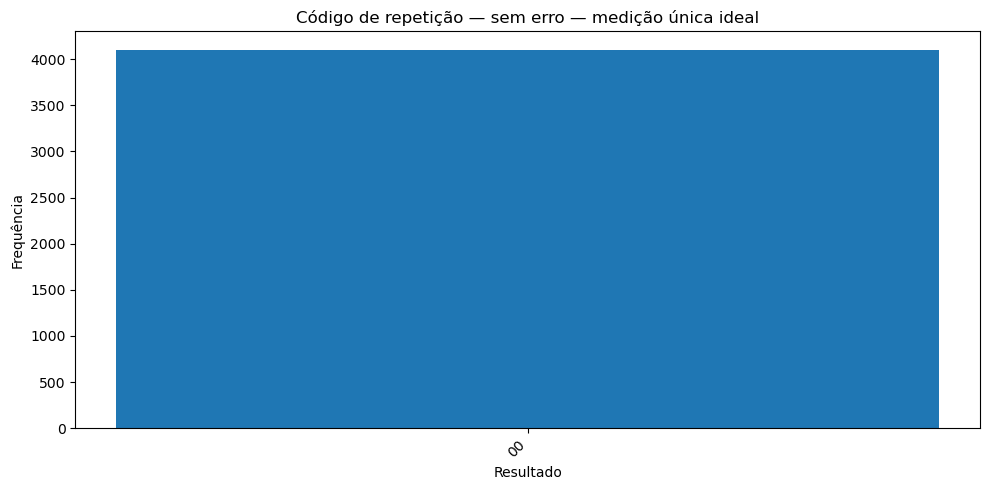

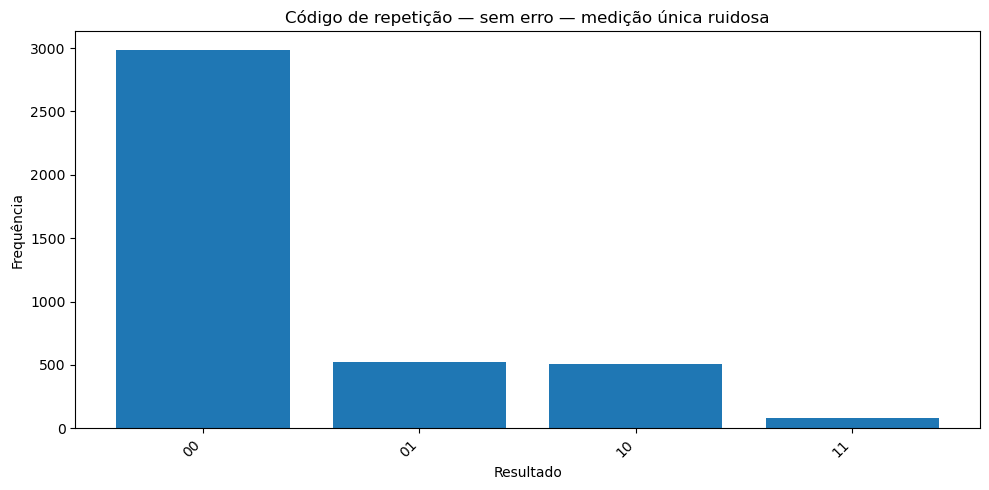

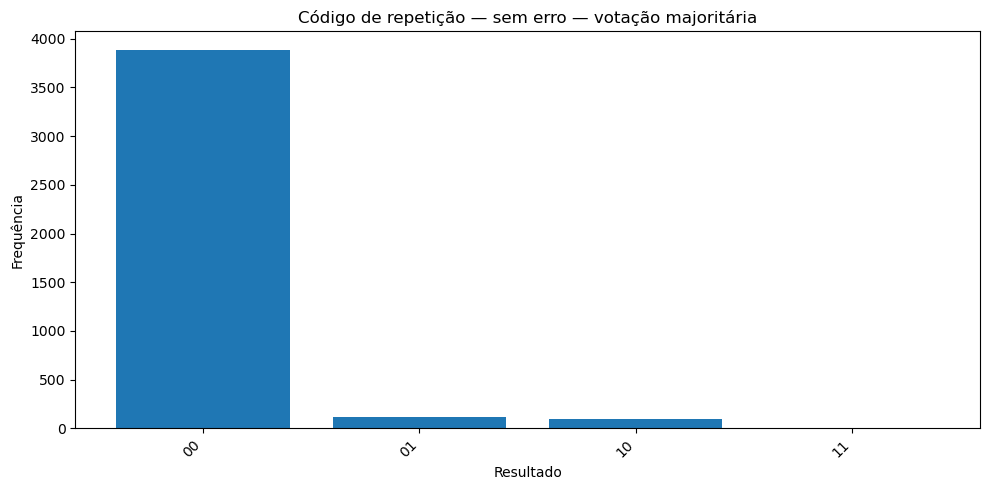


Código de repetição — erro X em q0

Síndrome — medição única ideal
------------------------------
          10 : 4096

Síndrome — medição única com ruído de leitura
---------------------------------------------
          10 : 2947
          00 : 541
          11 : 518
          01 : 90

Síndrome — 5 medições ruidosas com votação majoritária
------------------------------------------------------
          10 : 3877
          11 : 115
          00 : 103
          01 : 1

Interpretação:
Medição única ideal:      10 -> erro provável em q0
Medição única ruidosa:    10 -> erro provável em q0
Medição repetida ruidosa: 10 -> erro provável em q0


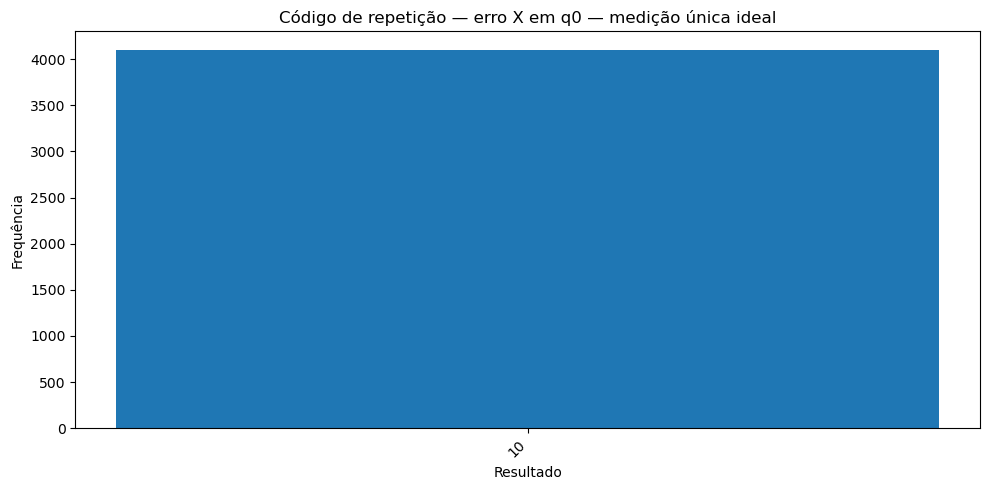

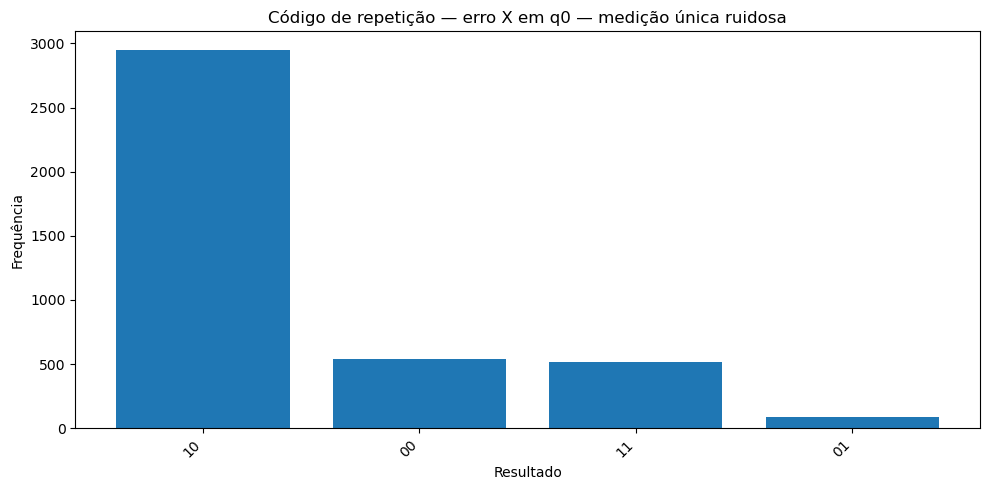

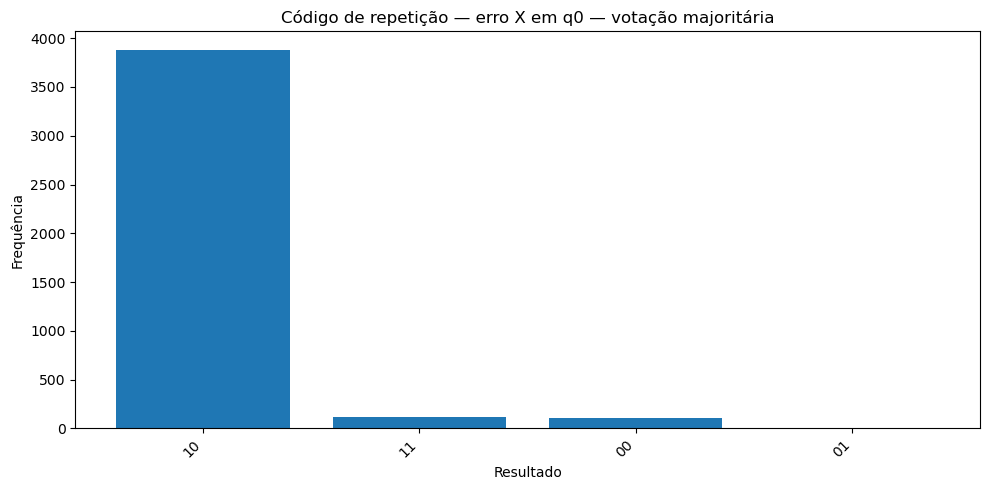


Código de repetição — erro X em q1

Síndrome — medição única ideal
------------------------------
          11 : 4096

Síndrome — medição única com ruído de leitura
---------------------------------------------
          11 : 2934
          10 : 531
          01 : 528
          00 : 103

Síndrome — 5 medições ruidosas com votação majoritária
------------------------------------------------------
          11 : 3890
          10 : 102
          01 : 102
          00 : 2

Interpretação:
Medição única ideal:      11 -> erro provável em q1
Medição única ruidosa:    11 -> erro provável em q1
Medição repetida ruidosa: 11 -> erro provável em q1


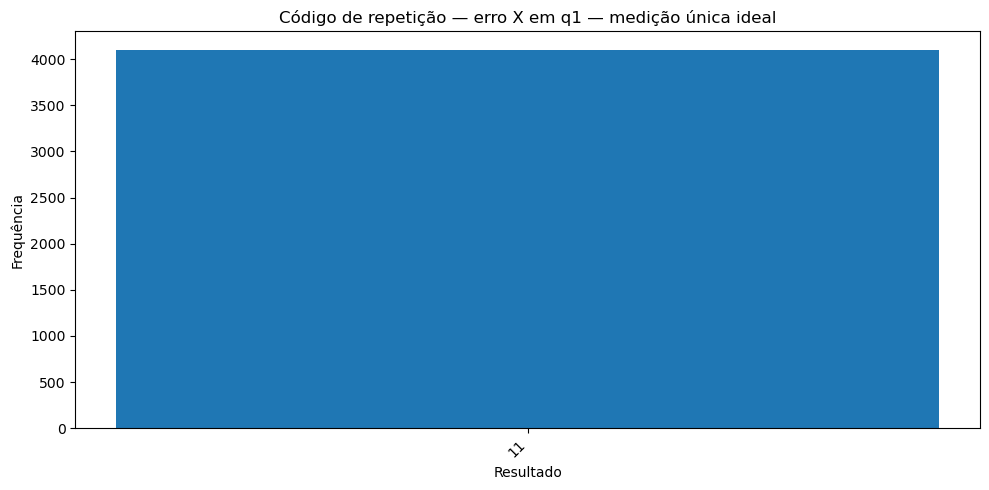

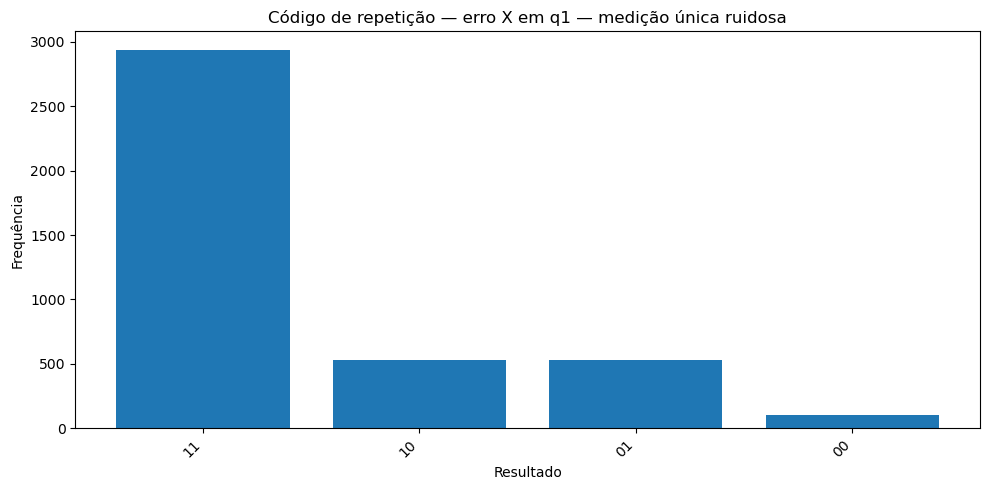

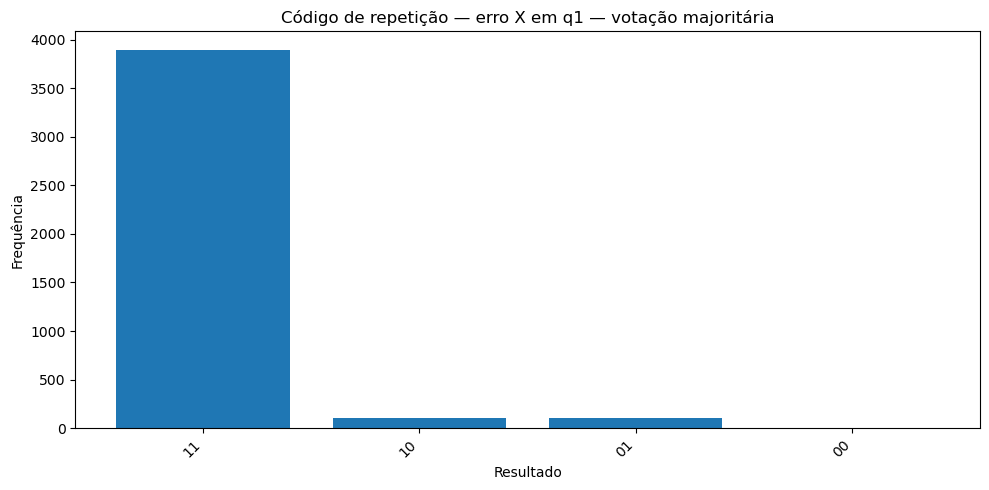


Código de repetição — erro X em q2

Síndrome — medição única ideal
------------------------------
          01 : 4096

Síndrome — medição única com ruído de leitura
---------------------------------------------
          01 : 2968
          00 : 539
          11 : 494
          10 : 95

Síndrome — 5 medições ruidosas com votação majoritária
------------------------------------------------------
          01 : 3892
          00 : 103
          11 : 100
          10 : 1

Interpretação:
Medição única ideal:      01 -> erro provável em q2
Medição única ruidosa:    01 -> erro provável em q2
Medição repetida ruidosa: 01 -> erro provável em q2


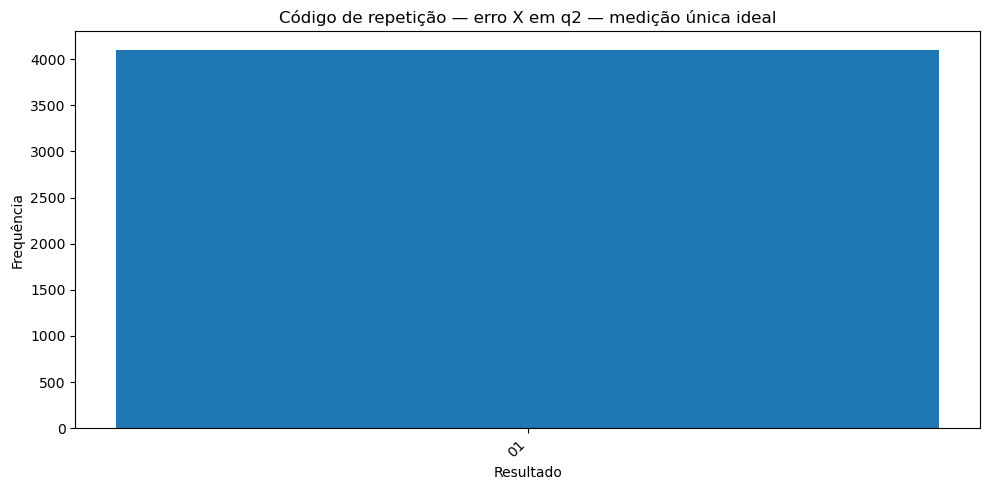

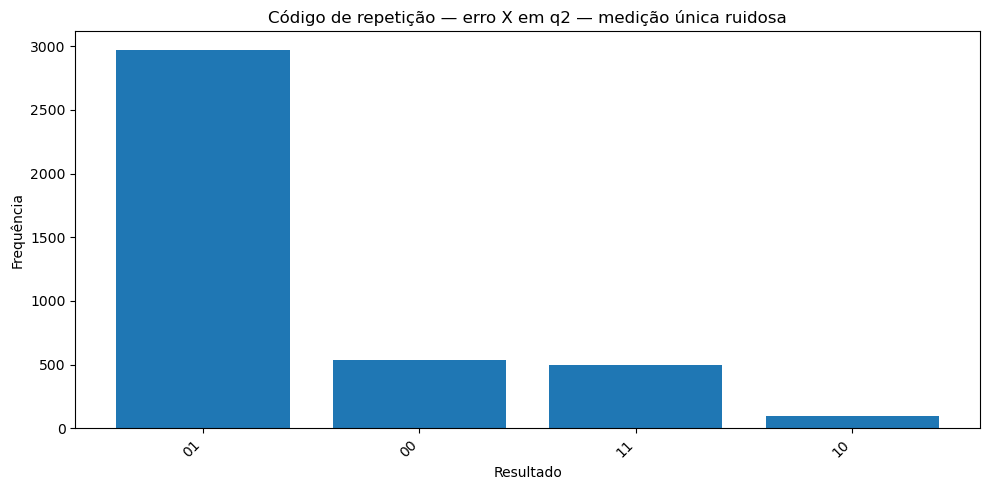

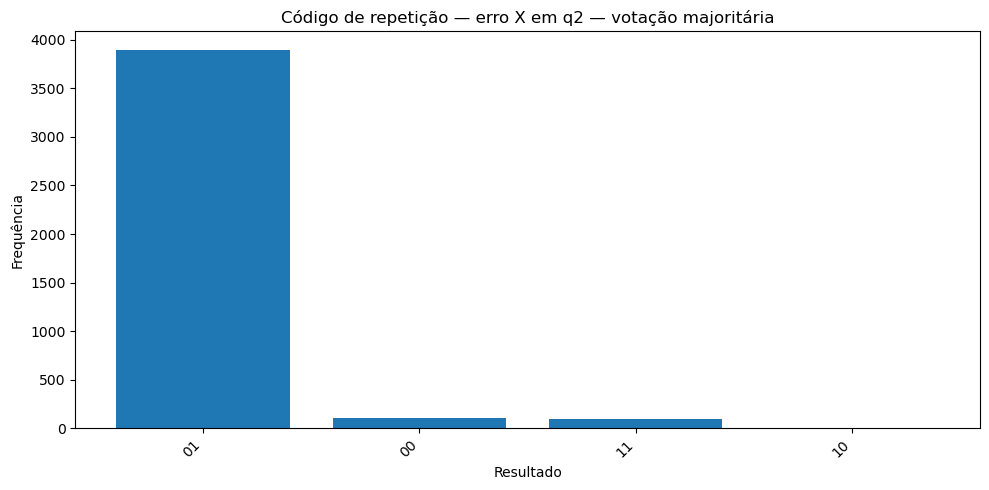


Código de Shor — sem erro

Ordem da síndrome de Shor:
s0 = Z0Z1
s1 = Z1Z2
s2 = Z3Z4
s3 = Z4Z5
s4 = Z6Z7
s5 = Z7Z8
s6 = X0X1X2X3X4X5
s7 = X3X4X5X6X7X8

Síndrome — medição única ideal
------------------------------
    00000000 : 4096

Síndrome — medição única com ruído de leitura
---------------------------------------------
    00000000 : 1096
    00010000 : 222
    10000000 : 204
    00000100 : 190
    00000010 : 189
    01000000 : 186
    00100000 : 182
    00000001 : 180
    00001000 : 171
    01000100 : 55

Síndrome — 5 medições ruidosas com votação majoritária
------------------------------------------------------
    00000000 : 3365
    00000001 : 92
    00000010 : 89
    01000000 : 87
    00100000 : 86
    00000100 : 82
    00010000 : 82
    00001000 : 75
    10000000 : 67
    00010010 : 8

Interpretação:
Medição única ideal:      00000000 -> sem erro detectável
Medição única ruidosa:    00000000 -> sem erro detectável
Medição repetida ruidosa: 00000000 -> sem erro detectável


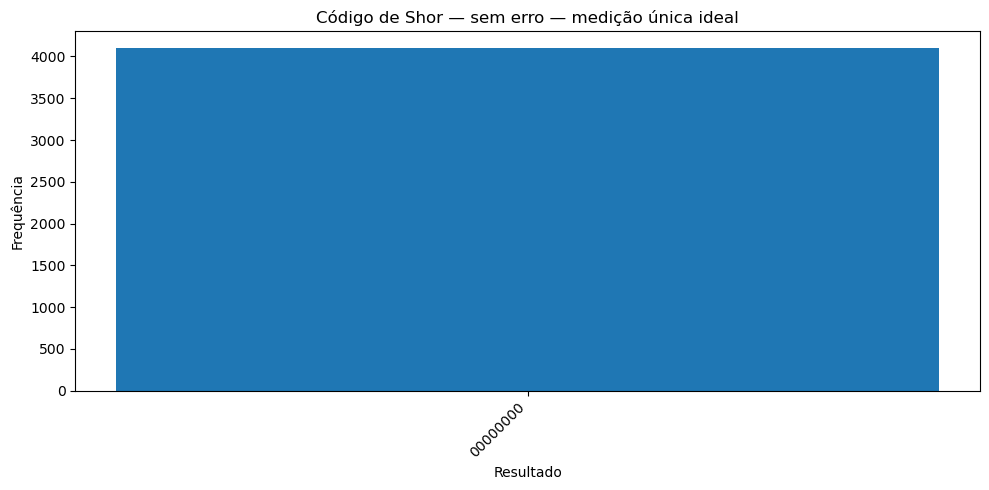

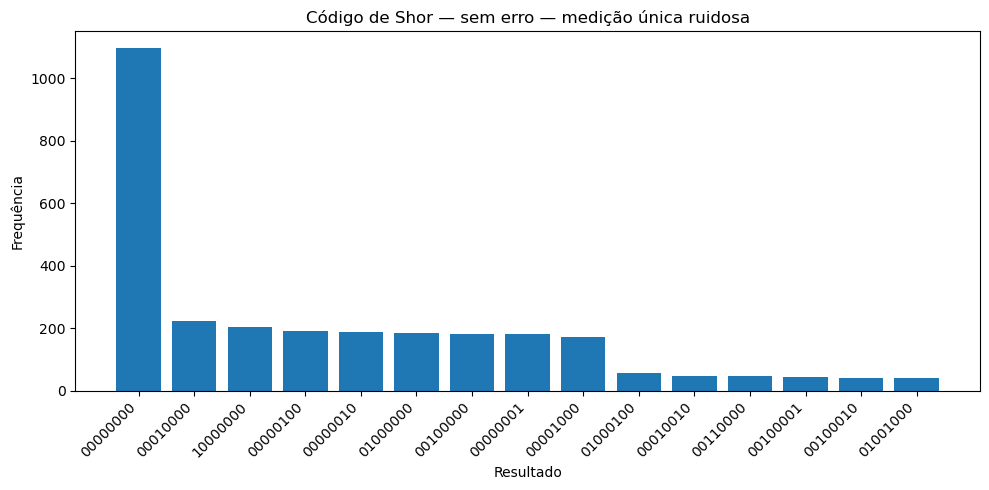

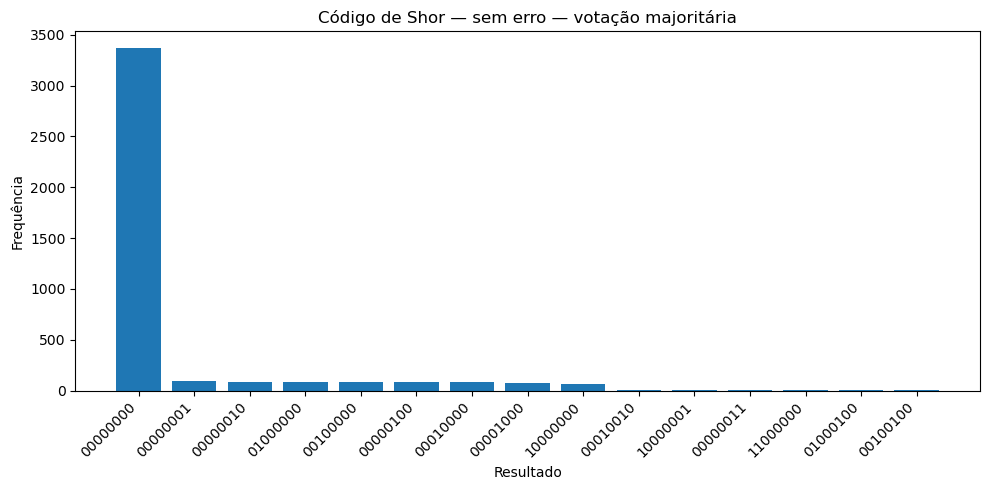


Código de Shor — erro X em q4

Ordem da síndrome de Shor:
s0 = Z0Z1
s1 = Z1Z2
s2 = Z3Z4
s3 = Z4Z5
s4 = Z6Z7
s5 = Z7Z8
s6 = X0X1X2X3X4X5
s7 = X3X4X5X6X7X8

Síndrome — medição única ideal
------------------------------
    00110000 : 4096

Síndrome — medição única com ruído de leitura
---------------------------------------------
    00110000 : 1108
    00010000 : 213
    01110000 : 208
    00110010 : 206
    00110001 : 194
    10110000 : 186
    00100000 : 185
    00110100 : 173
    00111000 : 173
    01110100 : 53

Síndrome — 5 medições ruidosas com votação majoritária
------------------------------------------------------
    00110000 : 3345
    00010000 : 99
    00110010 : 95
    00110001 : 92
    00100000 : 89
    01110000 : 88
    00110100 : 83
    00111000 : 77
    10110000 : 69
    00110011 : 6

Interpretação:
Medição única ideal:      00110000 -> erro tipo X provável nos qubits [4]
Medição única ruidosa:    00110000 -> erro tipo X provável nos qubits [4]
Medição repetida ruidos

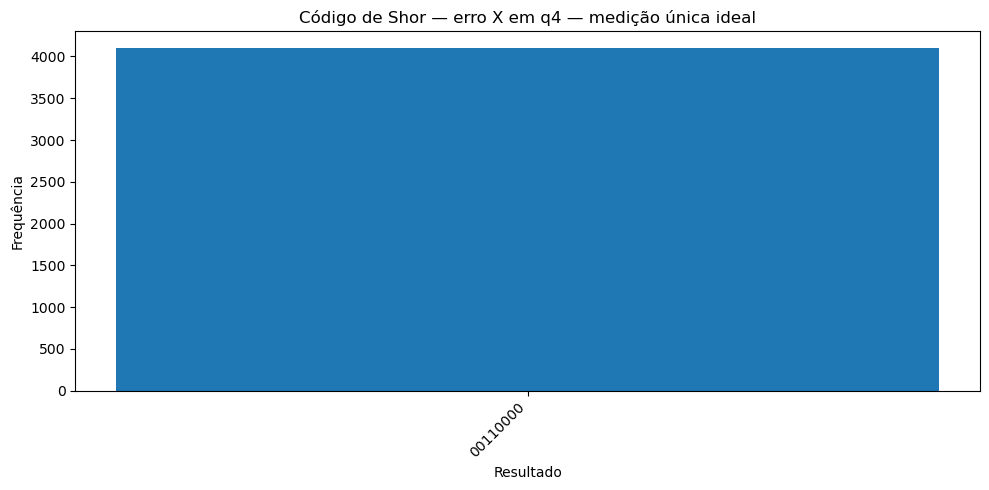

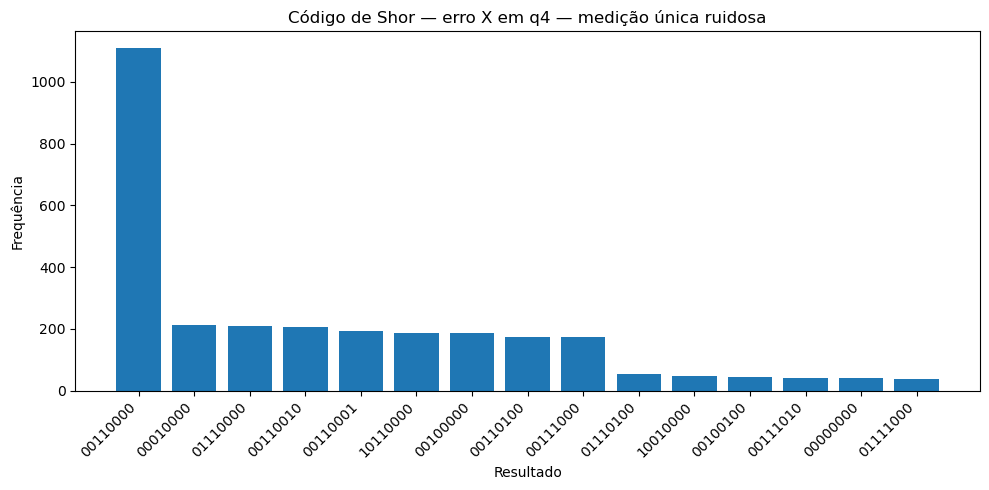

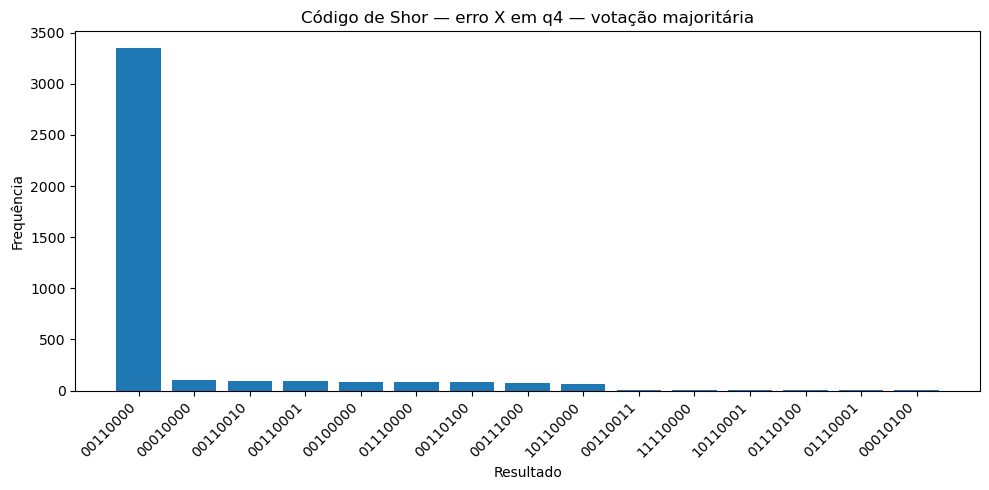


Código de Shor — erro Z em q4

Ordem da síndrome de Shor:
s0 = Z0Z1
s1 = Z1Z2
s2 = Z3Z4
s3 = Z4Z5
s4 = Z6Z7
s5 = Z7Z8
s6 = X0X1X2X3X4X5
s7 = X3X4X5X6X7X8

Síndrome — medição única ideal
------------------------------
    00000011 : 4096

Síndrome — medição única com ruído de leitura
---------------------------------------------
    00000011 : 1089
    00010011 : 222
    00100011 : 206
    10000011 : 203
    00000010 : 193
    00000111 : 187
    00000001 : 185
    00001011 : 177
    01000011 : 176
    00010001 : 46

Síndrome — 5 medições ruidosas com votação majoritária
------------------------------------------------------
    00000011 : 3358
    00000010 : 102
    00000001 : 91
    00010011 : 89
    01000011 : 87
    00100011 : 85
    00000111 : 81
    00001011 : 73
    10000011 : 70
    11000011 : 4

Interpretação:
Medição única ideal:      00000011 -> erro tipo Z provável no segundo bloco: q3, q4, q5
Medição única ruidosa:    00000011 -> erro tipo Z provável no segundo bloco: q3, q

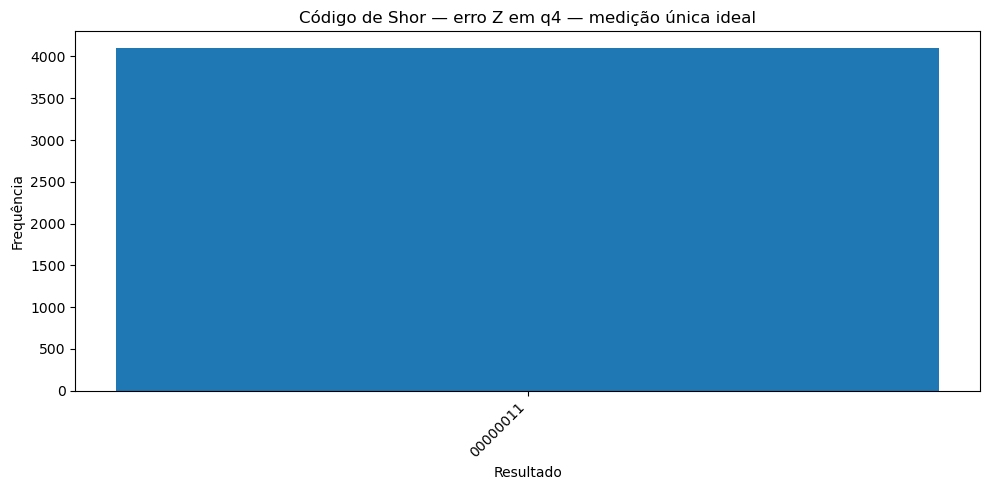

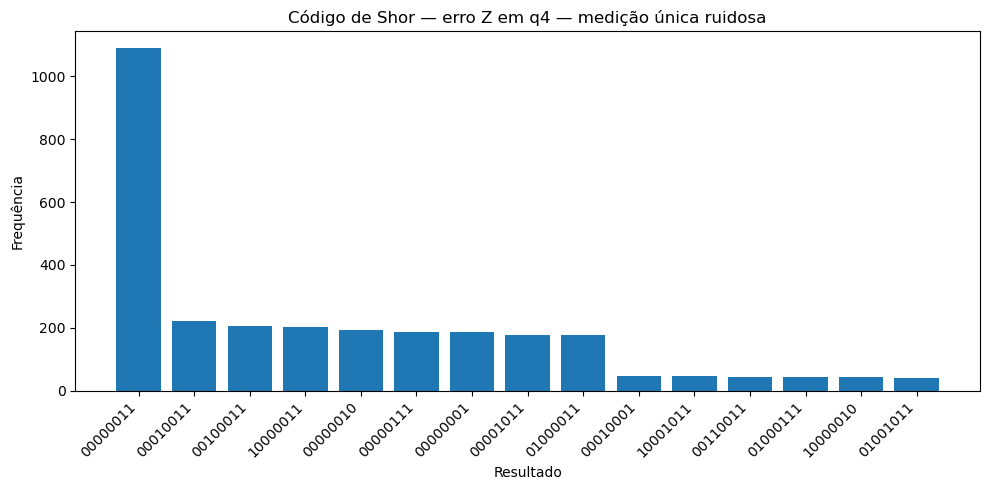

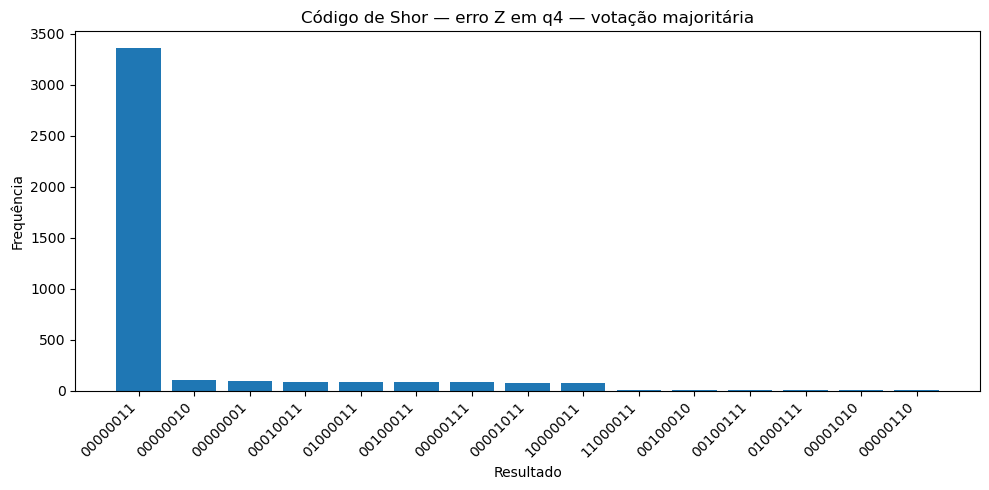


Código de Shor — erro Y em q4

Ordem da síndrome de Shor:
s0 = Z0Z1
s1 = Z1Z2
s2 = Z3Z4
s3 = Z4Z5
s4 = Z6Z7
s5 = Z7Z8
s6 = X0X1X2X3X4X5
s7 = X3X4X5X6X7X8

Síndrome — medição única ideal
------------------------------
    00110011 : 4096

Síndrome — medição única com ruído de leitura
---------------------------------------------
    00110011 : 1131
    00100011 : 202
    00110001 : 195
    00110111 : 191
    01110011 : 190
    00111011 : 190
    00010011 : 185
    10110011 : 177
    00110010 : 175
    10010011 : 49

Síndrome — 5 medições ruidosas com votação majoritária
------------------------------------------------------
    00110011 : 3343
    00110010 : 103
    00010011 : 97
    00110001 : 91
    00100011 : 91
    01110011 : 88
    00110111 : 82
    00111011 : 74
    10110011 : 71
    11110011 : 5

Interpretação:
Medição única ideal:      00110011 -> erro tipo X provável nos qubits [4]; erro tipo Z provável no segundo bloco: q3, q4, q5
Medição única ruidosa:    00110011 -> erro ti

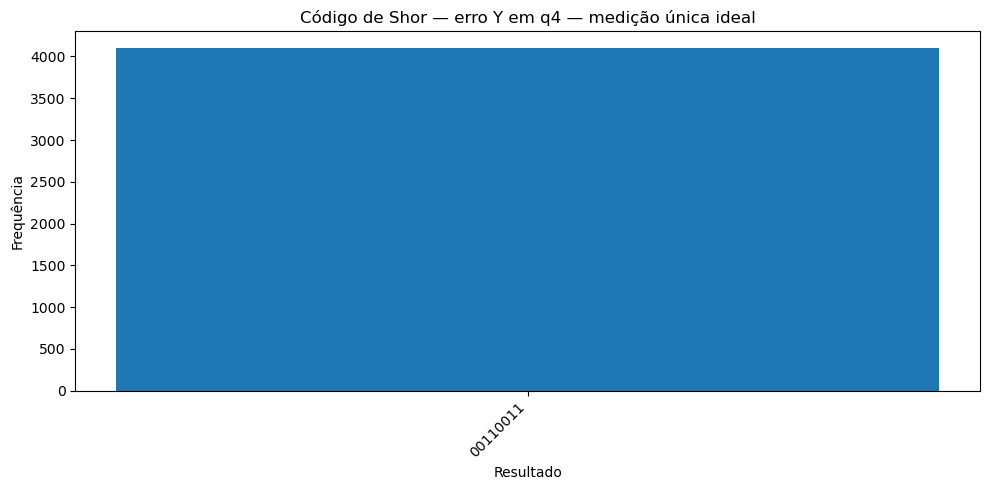

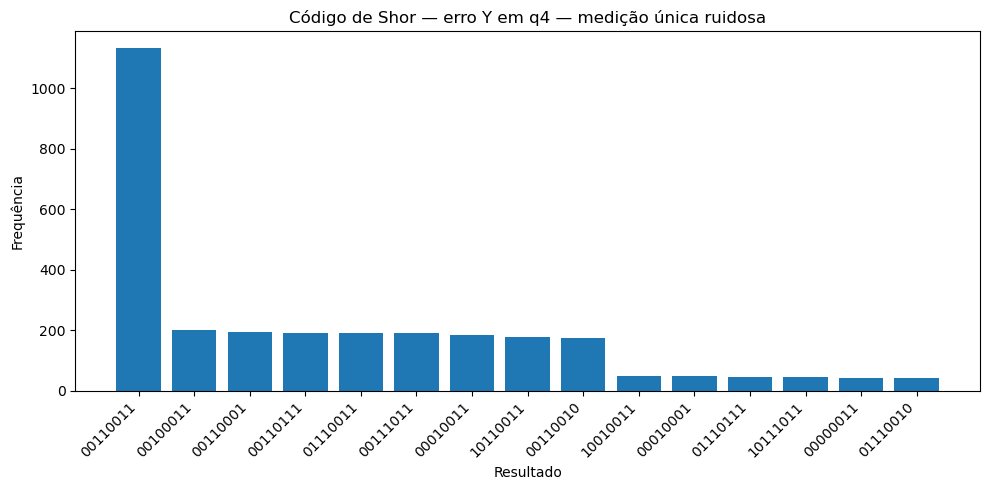

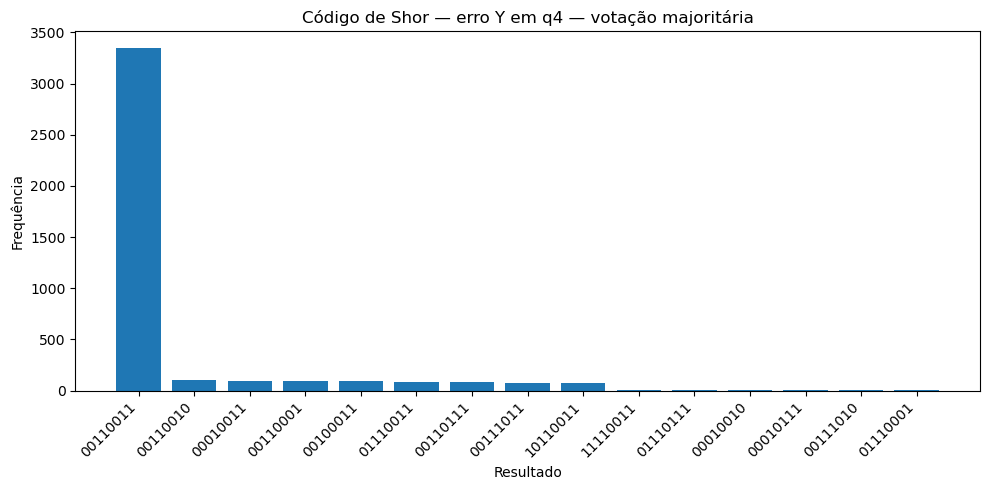


CIRCUITO DE REPETIÇÃO — UMA RODADA, ERRO X EM q1
                                               ░ 
q_0: ──■────■─────────■────────────────────────░─
     ┌─┴─┐  │  ┌───┐  │                        ░ 
q_1: ┤ X ├──┼──┤ X ├──┼────■───────■───────────░─
     └───┘┌─┴─┐└───┘  │    │       │           ░ 
q_2: ─────┤ X ├───────┼────┼───────┼────■──────░─
          └───┘     ┌─┴─┐┌─┴─┐┌─┐  │    │      ░ 
q_3: ───────────────┤ X ├┤ X ├┤M├──┼────┼──────░─
                    └───┘└───┘└╥┘┌─┴─┐┌─┴─┐┌─┐ ░ 
q_4: ──────────────────────────╫─┤ X ├┤ X ├┤M├─░─
                               ║ └───┘└───┘└╥┘ ░ 
c: 2/══════════════════════════╩════════════╩════
                               0            1    

CIRCUITO DE SHOR — 5 RODADAS, ERRO X EM q4
Número de qubits do circuito de Shor: 17
Número de bits clássicos: 40

Observação:
O circuito de Shor usa 17 qubits: 9 dados + 8 ancillas reutilizadas.
O número de bits clássicos cresce com as rodadas, mas o número de qubits não cresce.

FIM DO PASSO 3


In [3]:
# ============================================================
# PASSO 3 — EXTRAÇÃO DE SÍNDROME E REPETIÇÃO DE MEDIÇÕES
# Versão corrigida: reutiliza ancillas com reset
# ============================================================
#
# Instalação recomendada:
# pip install qiskit qiskit-aer matplotlib pylatexenc
#
# Objetivos:
# 1. Construir circuitos de extração de síndrome;
# 2. Comparar medição única ideal, medição única ruidosa e medições repetidas;
# 3. Simular ruído de leitura nas ancillas;
# 4. Usar votação majoritária clássica para inferir a síndrome mais provável;
# 5. Evitar crescimento artificial do número de qubits.
#
# ============================================================

from collections import Counter

from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, ReadoutError

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None


# ============================================================
# CONFIGURAÇÕES
# ============================================================

SHOTS = 4096
SEED = 1234

N_ROUNDS = 5
READOUT_ERROR_PROBABILITY = 0.15

MAKE_PLOTS = True


# ============================================================
# FUNÇÕES GERAIS
# ============================================================

def simulate_counts(qc, shots=SHOTS, noise_model=None, seed=SEED):
    """
    Executa um circuito no AerSimulator e retorna os counts.
    """

    simulator = AerSimulator(noise_model=noise_model)

    compiled = transpile(
        qc,
        simulator,
        optimization_level=0
    )

    job = simulator.run(
        compiled,
        shots=shots,
        seed_simulator=seed
    )

    result = job.result()
    return result.get_counts()


def inject_pauli_error(qc, qubit, pauli):
    """
    Injeta um erro Pauli controlado em um qubit físico.
    """

    if pauli is None:
        return

    pauli = pauli.upper()

    if pauli == "X":
        qc.x(qubit)
    elif pauli == "Y":
        qc.y(qubit)
    elif pauli == "Z":
        qc.z(qubit)
    else:
        raise ValueError("pauli deve ser 'X', 'Y', 'Z' ou None.")


def classical_bit(bitstring, cindex):
    """
    Lê o bit clássico c[cindex] de uma bitstring do Qiskit.

    O Qiskit imprime os bits clássicos na ordem:
    c[n-1] ... c[1] c[0]

    Portanto, para acessar c[i], invertemos a string.
    """

    clean = bitstring.replace(" ", "")
    return int(clean[::-1][cindex])


def build_ancilla_readout_noise_model(ancilla_qubits, p_readout=0.10):
    """
    Constrói um modelo de ruído de leitura aplicado apenas às ancillas.

    p_readout:
        probabilidade de trocar 0 por 1 ou 1 por 0 durante a medição.
    """

    noise_model = NoiseModel()

    readout_error = ReadoutError([
        [1.0 - p_readout, p_readout],
        [p_readout, 1.0 - p_readout]
    ])

    for qubit in ancilla_qubits:
        noise_model.add_readout_error(readout_error, [qubit])

    return noise_model


def top_counts(counts, k=10):
    """
    Retorna os k resultados mais frequentes.
    """

    return dict(
        sorted(
            counts.items(),
            key=lambda item: item[1],
            reverse=True
        )[:k]
    )


def most_likely(counts):
    """
    Retorna o resultado mais provável de uma distribuição.
    """

    if len(counts) == 0:
        return None, 0

    return max(counts.items(), key=lambda item: item[1])


def plot_distribution(counts, title, filename=None, top_k=15):
    """
    Plota uma distribuição de frequências.
    """

    if plt is None:
        print("Matplotlib não está instalado. Gráfico ignorado.")
        return

    data = top_counts(counts, k=top_k)

    labels = list(data.keys())
    values = list(data.values())

    plt.figure(figsize=(10, 5))
    plt.bar(labels, values)
    plt.title(title)
    plt.xlabel("Resultado")
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()

    if filename is not None:
        plt.savefig(filename, dpi=200, bbox_inches="tight")

    plt.show()


def print_distribution(title, counts, k=10):
    """
    Imprime uma distribuição de frequências.
    """

    print("\n" + title)
    print("-" * len(title))

    for key, value in top_counts(counts, k=k).items():
        print(f"{key:>12s} : {value}")


def syndrome_from_bitstring(bitstring, n_stabilizers, round_index):
    """
    Extrai a síndrome de uma rodada específica.

    Se há m estabilizadores, a rodada r ocupa os bits clássicos:

    c[r*m], c[r*m + 1], ..., c[r*m + m - 1]
    """

    start = round_index * n_stabilizers

    bits = [
        str(classical_bit(bitstring, start + s))
        for s in range(n_stabilizers)
    ]

    return "".join(bits)


def single_round_syndrome_counts(counts, n_stabilizers, round_index=0):
    """
    Agrega a distribuição de síndromes de uma rodada específica.
    """

    syndrome_counts = Counter()

    for bitstring, frequency in counts.items():
        syndrome = syndrome_from_bitstring(
            bitstring,
            n_stabilizers=n_stabilizers,
            round_index=round_index
        )

        syndrome_counts[syndrome] += frequency

    return dict(syndrome_counts)


def majority_syndrome_from_bitstring(
    bitstring,
    n_stabilizers,
    n_rounds,
    tie_value=0
):
    """
    Calcula a síndrome final por votação majoritária bit a bit.
    """

    majority_bits = []

    for s in range(n_stabilizers):
        votes = 0

        for r in range(n_rounds):
            cindex = r * n_stabilizers + s
            votes += classical_bit(bitstring, cindex)

        if votes > n_rounds / 2:
            bit = 1
        elif votes < n_rounds / 2:
            bit = 0
        else:
            bit = tie_value

        majority_bits.append(str(bit))

    return "".join(majority_bits)


def majority_syndrome_counts(counts, n_stabilizers, n_rounds, tie_value=0):
    """
    Agrega a distribuição de síndromes após votação majoritária.
    """

    voted_counts = Counter()

    for bitstring, frequency in counts.items():
        syndrome = majority_syndrome_from_bitstring(
            bitstring=bitstring,
            n_stabilizers=n_stabilizers,
            n_rounds=n_rounds,
            tie_value=tie_value
        )

        voted_counts[syndrome] += frequency

    return dict(voted_counts)


# ============================================================
# CÓDIGO DE REPETIÇÃO DE 3 QUBITS
# ============================================================

def encode_repetition_bitflip(qc, data_qubits=(0, 1, 2), logical_state="0"):
    """
    Codifica um qubit lógico no código de repetição de 3 qubits.

    |0>_L = |000>
    |1>_L = |111>
    """

    q0, q1, q2 = data_qubits

    if logical_state == "0":
        pass
    elif logical_state == "1":
        qc.x(q0)
    else:
        raise ValueError("logical_state deve ser '0' ou '1'.")

    qc.cx(q0, q1)
    qc.cx(q0, q2)


def repetition_ancilla_qubits():
    """
    Ancillas reutilizadas no código de repetição.

    q0, q1, q2: dados
    q3, q4: ancillas
    """

    return [3, 4]


def build_repetition_syndrome_circuit(
    logical_state="0",
    error_qubit=None,
    pauli_error=None,
    n_rounds=1
):
    """
    Circuito de extração de síndrome para o código de repetição.

    Qubits:
        q0, q1, q2: qubits de dados
        q3, q4: ancillas reutilizadas

    Estabilizadores:
        S0 = Z0 Z1
        S1 = Z1 Z2

    Síndrome:
        s0 s1

    Interpretação:
        00 -> sem erro detectável
        10 -> erro provável em q0
        11 -> erro provável em q1
        01 -> erro provável em q2
    """

    n_data = 3
    n_ancillas = 2
    n_stabilizers = 2
    n_classical = n_rounds * n_stabilizers

    qc = QuantumCircuit(n_data + n_ancillas, n_classical)

    encode_repetition_bitflip(
        qc,
        data_qubits=(0, 1, 2),
        logical_state=logical_state
    )

    if error_qubit is not None:
        inject_pauli_error(qc, error_qubit, pauli_error)

    anc_s0 = 3
    anc_s1 = 4

    for r in range(n_rounds):
        c_s0 = r * n_stabilizers + 0
        c_s1 = r * n_stabilizers + 1

        # Mede S0 = Z0 Z1
        qc.cx(0, anc_s0)
        qc.cx(1, anc_s0)
        qc.measure(anc_s0, c_s0)

        # Mede S1 = Z1 Z2
        qc.cx(1, anc_s1)
        qc.cx(2, anc_s1)
        qc.measure(anc_s1, c_s1)

        if r < n_rounds - 1:
            qc.reset(anc_s0)
            qc.reset(anc_s1)

        qc.barrier()

    return qc


def interpret_repetition_syndrome(syndrome):
    """
    Interpreta a síndrome do código de repetição.
    """

    table = {
        "00": "sem erro detectável",
        "10": "erro provável em q0",
        "11": "erro provável em q1",
        "01": "erro provável em q2",
    }

    return table.get(syndrome, "síndrome desconhecida")


# ============================================================
# CÓDIGO DE SHOR DE 9 QUBITS
# ============================================================

def encode_shor_block(qc, offset=0, logical_state="0"):
    """
    Codifica um qubit lógico no código de Shor de 9 qubits.

    Estados permitidos:
        "0", "1", "+", "-"
    """

    q = [offset + i for i in range(9)]

    if logical_state == "0":
        pass
    elif logical_state == "1":
        qc.x(q[0])
    elif logical_state == "+":
        qc.h(q[0])
    elif logical_state == "-":
        qc.x(q[0])
        qc.h(q[0])
    else:
        raise ValueError("logical_state deve ser '0', '1', '+' ou '-'.")

    # Camada contra phase flip
    qc.cx(q[0], q[3])
    qc.cx(q[0], q[6])

    qc.h(q[0])
    qc.h(q[3])
    qc.h(q[6])

    # Camada contra bit flip
    qc.cx(q[0], q[1])
    qc.cx(q[0], q[2])

    qc.cx(q[3], q[4])
    qc.cx(q[3], q[5])

    qc.cx(q[6], q[7])
    qc.cx(q[6], q[8])


SHOR_STABILIZERS = [
    ("Z0Z1", "Z", [0, 1]),
    ("Z1Z2", "Z", [1, 2]),
    ("Z3Z4", "Z", [3, 4]),
    ("Z4Z5", "Z", [4, 5]),
    ("Z6Z7", "Z", [6, 7]),
    ("Z7Z8", "Z", [7, 8]),
    ("X0X1X2X3X4X5", "X", [0, 1, 2, 3, 4, 5]),
    ("X3X4X5X6X7X8", "X", [3, 4, 5, 6, 7, 8]),
]


def measure_pauli_product(qc, data_qubits, pauli, ancilla, classical_bit_index):
    """
    Mede um produto de Pauli usando uma ancilla.

    Para estabilizadores Z:
        mede diretamente a paridade em base computacional.

    Para estabilizadores X:
        aplica H nos dados, mede como Z, depois desfaz H.
    """

    pauli = pauli.upper()

    if pauli == "Z":
        for q in data_qubits:
            qc.cx(q, ancilla)

        qc.measure(ancilla, classical_bit_index)

    elif pauli == "X":
        for q in data_qubits:
            qc.h(q)

        for q in data_qubits:
            qc.cx(q, ancilla)

        for q in data_qubits:
            qc.h(q)

        qc.measure(ancilla, classical_bit_index)

    else:
        raise ValueError("pauli deve ser 'X' ou 'Z'.")


def shor_ancilla_qubits():
    """
    Ancillas reutilizadas no código de Shor.

    q0, ..., q8: dados
    q9, ..., q16: ancillas
    """

    return list(range(9, 17))


def build_shor_syndrome_circuit(
    logical_state="0",
    error_qubit=None,
    pauli_error=None,
    n_rounds=1
):
    """
    Circuito de extração de síndrome para o código de Shor.

    Qubits:
        q0, ..., q8: qubits de dados
        q9, ..., q16: ancillas reutilizadas

    Ordem da síndrome:
        s0 = Z0Z1
        s1 = Z1Z2
        s2 = Z3Z4
        s3 = Z4Z5
        s4 = Z6Z7
        s5 = Z7Z8
        s6 = X0X1X2X3X4X5
        s7 = X3X4X5X6X7X8

    Total de qubits:
        9 dados + 8 ancillas = 17 qubits

    Mesmo com várias rodadas, o número de qubits permanece 17.
    """

    n_data = 9
    n_stabilizers = len(SHOR_STABILIZERS)
    n_ancillas = n_stabilizers
    n_classical = n_rounds * n_stabilizers

    qc = QuantumCircuit(n_data + n_ancillas, n_classical)

    encode_shor_block(
        qc,
        offset=0,
        logical_state=logical_state
    )

    if error_qubit is not None:
        inject_pauli_error(qc, error_qubit, pauli_error)

    for r in range(n_rounds):
        for s, (_, pauli, data_qubits) in enumerate(SHOR_STABILIZERS):
            ancilla = n_data + s
            cbit = r * n_stabilizers + s

            measure_pauli_product(
                qc,
                data_qubits=data_qubits,
                pauli=pauli,
                ancilla=ancilla,
                classical_bit_index=cbit
            )

        if r < n_rounds - 1:
            for ancilla in shor_ancilla_qubits():
                qc.reset(ancilla)

        qc.barrier()

    return qc


def interpret_shor_syndrome(syndrome):
    """
    Interpreta parcialmente a síndrome do código de Shor.

    A síndrome possui 8 bits:
        s0 s1 s2 s3 s4 s5 s6 s7

    s0,...,s5:
        detectam erros X nos blocos de três qubits.

    s6,s7:
        detectam em qual bloco ocorreu erro Z.
    """

    if syndrome is None:
        return "síndrome indefinida"

    if len(syndrome) != 8:
        return "síndrome inválida para o código de Shor"

    z_part = syndrome[:6]
    x_part = syndrome[6:]

    bit_flip_errors = []

    triples = [
        (z_part[0:2], (0, 1, 2)),
        (z_part[2:4], (3, 4, 5)),
        (z_part[4:6], (6, 7, 8)),
    ]

    for pair, qubits in triples:
        q0, q1, q2 = qubits

        if pair == "10":
            bit_flip_errors.append(q0)
        elif pair == "11":
            bit_flip_errors.append(q1)
        elif pair == "01":
            bit_flip_errors.append(q2)

    if x_part == "00":
        phase_block = None
    elif x_part == "10":
        phase_block = "primeiro bloco: q0, q1, q2"
    elif x_part == "11":
        phase_block = "segundo bloco: q3, q4, q5"
    elif x_part == "01":
        phase_block = "terceiro bloco: q6, q7, q8"
    else:
        phase_block = "indeterminado"

    messages = []

    if not bit_flip_errors and phase_block is None:
        messages.append("sem erro detectável")

    if bit_flip_errors:
        messages.append(f"erro tipo X provável nos qubits {bit_flip_errors}")

    if phase_block is not None:
        messages.append(f"erro tipo Z provável no {phase_block}")

    return "; ".join(messages)


# ============================================================
# ROTINAS DE COMPARAÇÃO
# ============================================================

def sanitize_filename(text):
    """
    Gera nome simples para arquivo de figura.
    """

    output = text.lower()
    output = output.replace(" ", "_")
    output = output.replace("—", "")
    output = output.replace(":", "")
    output = output.replace("ç", "c")
    output = output.replace("ã", "a")
    output = output.replace("á", "a")
    output = output.replace("é", "e")
    output = output.replace("í", "i")
    output = output.replace("ó", "o")
    output = output.replace("ú", "u")

    return output


def run_repetition_experiment(
    title,
    logical_state="0",
    error_qubit=None,
    pauli_error=None,
    readout_error_probability=READOUT_ERROR_PROBABILITY,
    n_rounds=N_ROUNDS,
    shots=SHOTS
):
    """
    Compara:
        1. medição única ideal;
        2. medição única ruidosa;
        3. medições repetidas ruidosas com votação majoritária.
    """

    n_stabilizers = 2

    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

    # --------------------------------------------------------
    # Medição única ideal
    # --------------------------------------------------------

    qc_single = build_repetition_syndrome_circuit(
        logical_state=logical_state,
        error_qubit=error_qubit,
        pauli_error=pauli_error,
        n_rounds=1
    )

    counts_single_ideal = simulate_counts(
        qc_single,
        shots=shots,
        noise_model=None
    )

    syndrome_single_ideal = single_round_syndrome_counts(
        counts_single_ideal,
        n_stabilizers=n_stabilizers,
        round_index=0
    )

    # --------------------------------------------------------
    # Medição única ruidosa
    # --------------------------------------------------------

    noise_single = build_ancilla_readout_noise_model(
        ancilla_qubits=repetition_ancilla_qubits(),
        p_readout=readout_error_probability
    )

    counts_single_noisy = simulate_counts(
        qc_single,
        shots=shots,
        noise_model=noise_single
    )

    syndrome_single_noisy = single_round_syndrome_counts(
        counts_single_noisy,
        n_stabilizers=n_stabilizers,
        round_index=0
    )

    # --------------------------------------------------------
    # Medições repetidas ruidosas
    # --------------------------------------------------------

    qc_repeated = build_repetition_syndrome_circuit(
        logical_state=logical_state,
        error_qubit=error_qubit,
        pauli_error=pauli_error,
        n_rounds=n_rounds
    )

    noise_repeated = build_ancilla_readout_noise_model(
        ancilla_qubits=repetition_ancilla_qubits(),
        p_readout=readout_error_probability
    )

    counts_repeated_noisy = simulate_counts(
        qc_repeated,
        shots=shots,
        noise_model=noise_repeated
    )

    syndrome_repeated_majority = majority_syndrome_counts(
        counts_repeated_noisy,
        n_stabilizers=n_stabilizers,
        n_rounds=n_rounds
    )

    # --------------------------------------------------------
    # Impressão dos resultados
    # --------------------------------------------------------

    print_distribution(
        "Síndrome — medição única ideal",
        syndrome_single_ideal
    )

    print_distribution(
        "Síndrome — medição única com ruído de leitura",
        syndrome_single_noisy
    )

    print_distribution(
        f"Síndrome — {n_rounds} medições ruidosas com votação majoritária",
        syndrome_repeated_majority
    )

    best_ideal, _ = most_likely(syndrome_single_ideal)
    best_noisy, _ = most_likely(syndrome_single_noisy)
    best_majority, _ = most_likely(syndrome_repeated_majority)

    print("\nInterpretação:")
    print(f"Medição única ideal:      {best_ideal} -> {interpret_repetition_syndrome(best_ideal)}")
    print(f"Medição única ruidosa:    {best_noisy} -> {interpret_repetition_syndrome(best_noisy)}")
    print(f"Medição repetida ruidosa: {best_majority} -> {interpret_repetition_syndrome(best_majority)}")

    # --------------------------------------------------------
    # Gráficos
    # --------------------------------------------------------

    if MAKE_PLOTS:
        safe_title = sanitize_filename(title)

        plot_distribution(
            syndrome_single_ideal,
            title=f"{title} — medição única ideal",
            filename=f"{safe_title}_single_ideal.png"
        )

        plot_distribution(
            syndrome_single_noisy,
            title=f"{title} — medição única ruidosa",
            filename=f"{safe_title}_single_noisy.png"
        )

        plot_distribution(
            syndrome_repeated_majority,
            title=f"{title} — votação majoritária",
            filename=f"{safe_title}_majority.png"
        )

    return {
        "qc_single": qc_single,
        "qc_repeated": qc_repeated,
        "single_ideal": syndrome_single_ideal,
        "single_noisy": syndrome_single_noisy,
        "repeated_majority": syndrome_repeated_majority,
    }


def run_shor_experiment(
    title,
    logical_state="0",
    error_qubit=None,
    pauli_error=None,
    readout_error_probability=READOUT_ERROR_PROBABILITY,
    n_rounds=N_ROUNDS,
    shots=SHOTS
):
    """
    Compara:
        1. medição única ideal;
        2. medição única ruidosa;
        3. medições repetidas ruidosas com votação majoritária.
    """

    n_stabilizers = len(SHOR_STABILIZERS)

    print("\n" + "=" * 80)
    print(title)
    print("=" * 80)

    print("\nOrdem da síndrome de Shor:")

    for i, (name, _, _) in enumerate(SHOR_STABILIZERS):
        print(f"s{i} = {name}")

    # --------------------------------------------------------
    # Medição única ideal
    # --------------------------------------------------------

    qc_single = build_shor_syndrome_circuit(
        logical_state=logical_state,
        error_qubit=error_qubit,
        pauli_error=pauli_error,
        n_rounds=1
    )

    counts_single_ideal = simulate_counts(
        qc_single,
        shots=shots,
        noise_model=None
    )

    syndrome_single_ideal = single_round_syndrome_counts(
        counts_single_ideal,
        n_stabilizers=n_stabilizers,
        round_index=0
    )

    # --------------------------------------------------------
    # Medição única ruidosa
    # --------------------------------------------------------

    noise_single = build_ancilla_readout_noise_model(
        ancilla_qubits=shor_ancilla_qubits(),
        p_readout=readout_error_probability
    )

    counts_single_noisy = simulate_counts(
        qc_single,
        shots=shots,
        noise_model=noise_single
    )

    syndrome_single_noisy = single_round_syndrome_counts(
        counts_single_noisy,
        n_stabilizers=n_stabilizers,
        round_index=0
    )

    # --------------------------------------------------------
    # Medições repetidas ruidosas
    # --------------------------------------------------------

    qc_repeated = build_shor_syndrome_circuit(
        logical_state=logical_state,
        error_qubit=error_qubit,
        pauli_error=pauli_error,
        n_rounds=n_rounds
    )

    noise_repeated = build_ancilla_readout_noise_model(
        ancilla_qubits=shor_ancilla_qubits(),
        p_readout=readout_error_probability
    )

    counts_repeated_noisy = simulate_counts(
        qc_repeated,
        shots=shots,
        noise_model=noise_repeated
    )

    syndrome_repeated_majority = majority_syndrome_counts(
        counts_repeated_noisy,
        n_stabilizers=n_stabilizers,
        n_rounds=n_rounds
    )

    # --------------------------------------------------------
    # Impressão dos resultados
    # --------------------------------------------------------

    print_distribution(
        "Síndrome — medição única ideal",
        syndrome_single_ideal
    )

    print_distribution(
        "Síndrome — medição única com ruído de leitura",
        syndrome_single_noisy
    )

    print_distribution(
        f"Síndrome — {n_rounds} medições ruidosas com votação majoritária",
        syndrome_repeated_majority
    )

    best_ideal, _ = most_likely(syndrome_single_ideal)
    best_noisy, _ = most_likely(syndrome_single_noisy)
    best_majority, _ = most_likely(syndrome_repeated_majority)

    print("\nInterpretação:")
    print(f"Medição única ideal:      {best_ideal} -> {interpret_shor_syndrome(best_ideal)}")
    print(f"Medição única ruidosa:    {best_noisy} -> {interpret_shor_syndrome(best_noisy)}")
    print(f"Medição repetida ruidosa: {best_majority} -> {interpret_shor_syndrome(best_majority)}")

    # --------------------------------------------------------
    # Gráficos
    # --------------------------------------------------------

    if MAKE_PLOTS:
        safe_title = sanitize_filename(title)

        plot_distribution(
            syndrome_single_ideal,
            title=f"{title} — medição única ideal",
            filename=f"{safe_title}_single_ideal.png"
        )

        plot_distribution(
            syndrome_single_noisy,
            title=f"{title} — medição única ruidosa",
            filename=f"{safe_title}_single_noisy.png"
        )

        plot_distribution(
            syndrome_repeated_majority,
            title=f"{title} — votação majoritária",
            filename=f"{safe_title}_majority.png"
        )

    return {
        "qc_single": qc_single,
        "qc_repeated": qc_repeated,
        "single_ideal": syndrome_single_ideal,
        "single_noisy": syndrome_single_noisy,
        "repeated_majority": syndrome_repeated_majority,
    }


# ============================================================
# EXECUÇÃO DOS EXPERIMENTOS
# ============================================================

print("\n============================================================")
print("PASSO 3 — EXTRAÇÃO DE SÍNDROME E REPETIÇÃO DE MEDIÇÕES")
print("============================================================")

print(f"\nShots: {SHOTS}")
print(f"Número de rodadas: {N_ROUNDS}")
print(f"Probabilidade de erro de leitura nas ancillas: {READOUT_ERROR_PROBABILITY}")


# ============================================================
# EXPERIMENTOS — CÓDIGO DE REPETIÇÃO
# ============================================================

result_rep_no_error = run_repetition_experiment(
    title="Código de repetição — sem erro",
    logical_state="0",
    error_qubit=None,
    pauli_error=None
)

result_rep_x_q0 = run_repetition_experiment(
    title="Código de repetição — erro X em q0",
    logical_state="0",
    error_qubit=0,
    pauli_error="X"
)

result_rep_x_q1 = run_repetition_experiment(
    title="Código de repetição — erro X em q1",
    logical_state="0",
    error_qubit=1,
    pauli_error="X"
)

result_rep_x_q2 = run_repetition_experiment(
    title="Código de repetição — erro X em q2",
    logical_state="0",
    error_qubit=2,
    pauli_error="X"
)


# ============================================================
# EXPERIMENTOS — CÓDIGO DE SHOR
# ============================================================

result_shor_no_error = run_shor_experiment(
    title="Código de Shor — sem erro",
    logical_state="0",
    error_qubit=None,
    pauli_error=None
)

result_shor_x_q4 = run_shor_experiment(
    title="Código de Shor — erro X em q4",
    logical_state="0",
    error_qubit=4,
    pauli_error="X"
)

result_shor_z_q4 = run_shor_experiment(
    title="Código de Shor — erro Z em q4",
    logical_state="0",
    error_qubit=4,
    pauli_error="Z"
)

result_shor_y_q4 = run_shor_experiment(
    title="Código de Shor — erro Y em q4",
    logical_state="0",
    error_qubit=4,
    pauli_error="Y"
)


# ============================================================
# INSPEÇÃO DOS CIRCUITOS
# ============================================================

print("\n============================================================")
print("CIRCUITO DE REPETIÇÃO — UMA RODADA, ERRO X EM q1")
print("============================================================")

qc_rep_example = build_repetition_syndrome_circuit(
    logical_state="0",
    error_qubit=1,
    pauli_error="X",
    n_rounds=1
)

print(qc_rep_example.draw(output="text"))


print("\n============================================================")
print("CIRCUITO DE SHOR — 5 RODADAS, ERRO X EM q4")
print("============================================================")

qc_shor_example = build_shor_syndrome_circuit(
    logical_state="0",
    error_qubit=4,
    pauli_error="X",
    n_rounds=N_ROUNDS
)

print(f"Número de qubits do circuito de Shor: {qc_shor_example.num_qubits}")
print(f"Número de bits clássicos: {qc_shor_example.num_clbits}")

print("\nObservação:")
print("O circuito de Shor usa 17 qubits: 9 dados + 8 ancillas reutilizadas.")
print("O número de bits clássicos cresce com as rodadas, mas o número de qubits não cresce.")


print("\n============================================================")
print("FIM DO PASSO 3")
print("============================================================")